# Machine Learning - Driven Bank Churn Prediction
## Unlocking Customer Retention Insights
## Analyzing Demographic and Financial Factors


### Customer churn - the loss of customers to a competitor or due to other factors, can have a significant impact on a bank’s profitability and long-term growth.
### Customer churn is a significant issue for banks, impacting revenue and customer lifetime value. 
### Bank churn analysis involves studying the factors influencing customers’ decisions to terminate their relationships with a bank. By understanding the reasons behind customer churn, banks can develop targeted strategies to address these issues and reduce the rate of customer attrition.

### Step 1:

### Definition of the PROBLEM STATEMENT and OBJECTIVE to BUILD an ML MODEL:
### The goal is to develop a machine learning model that predicts whether a customer will churn (leave the bank) based on their demographic, financial, and account activity data

### Objective:  
##### 1. To build a predictive model to classify customers as likely to churn (Exited = 1) or stay (Exited = 0).
##### 2. Identify key factors influencing customer attrition.
##### 3. Provide actionable insights for customer retention strategies.

### Step 2: Data Acquisition

###### Step 2.1. Importing possibly necessary libararies 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt


%matplotlib inline 
#The visuals by Matplotlib are displayed directly below the code cell rather than 
#in a separate window.


import warnings
warnings.filterwarnings("ignore")

import scipy.stats as stats

##### Step 2.2:
    1. We have ONE excel file named 'Bank_Churn_Messy.xlsx' which has TWO sheets namely 'Customer_info' and 'Account_info'
    2. I have made TWO separate excel sheets out of it namely Bank_churn_Customer_info and Bank_churn_Account_info
    3. I have merged them using PANDAS

In [3]:
# Implementation of Step 2.2 mentioned above

Customer_info = pd.read_excel("Bank_churn_Customer_info.xlsx")
Account_info = pd.read_excel("Bank_churn_Account_info.xlsx")

data_1 = pd.merge(Customer_info,Account_info , on = 'CustomerId', how = 'outer' )

data_1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


##### Field Description
1. CustomerId ---- A unique identifier for each customer
2. Surname ----	The customer's last name
3. CreditScore ---	A numerical value representing the customer's credit score
4. Geography ---- The country where the customer resides (France, Spain or Germany)
5. Gender ---- The customer's gender (Male or Female)
6. Age ----	The customer's age
7. Tenure ---- The number of years the customer has been with the bank
8. Balance ----	The customer's account balance
9. NumOfProducts ---- The number of bank products the customer uses (e.g., savings account, credit card)
10. HasCrCard ---- Whether the customer has a credit card (1 = yes, 0 = no)
11. IsActiveMember ----	Whether the customer is an active member (1 = yes, 0 = no)
12. EstimatedSalary ---- The estimated salary of the customer
13. Exited ----	Whether the customer has churned (1 = yes, 0 = no)

In [4]:
data_1.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
9999,15682355,Sabbatini,772,Germany,Male,42.0,3,€92888.52,€75075.31,2,No,3,No,1
10000,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,4,No,0
10001,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,4,No,0
10002,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,4,No,0
10003,15628319,Walker,792,French,Female,28.0,4,€38190.78,€130142.79,1,No,4,No,0


### Step 3: Exploratory Data Analysis ---- EDA

#### Step 3.1. Checking the shape of the dataset and dropping the duplicate rows 

In [5]:
data_1.shape

(10004, 14)

In [6]:
data_1.drop_duplicates(inplace = True)
data_1.shape

(10000, 14)

#### Step 3.2. Getting to know the datatypes of the Dataset

In [7]:
data_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure_x         10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  Tenure_y         10000 non-null  int64  
 12  IsActiveMember   10000 non-null  object 
 13  Exited           10000 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


##### From the above step we are able to infer that:

    3.2.1. We can drop the 'CustomerID', 'Surname' column as it of no use in the Exit Prediction.
    3.2.2. There are two columns with Tenure name ('Tenure_x' , 'Tenure_y'), we can drop one of them
    3.2.3. We could see that the 'EstimatedSalary' and 'Balance' columns are of data type 'object' and we need to convert them to 'int' or 'float'

In [8]:
# Implementing above changes:
# Step 3.2.1

data_1 = data_1.drop(['CustomerId'], axis = 1)
data_1 = data_1.drop(['Surname'], axis = 1)

In [9]:
# Step 3.2.2

data_1 = data_1.drop(['Tenure_y'], axis = 1)

In [10]:
# Renaming 'Tenure_x' to 'Tenure'
data_1.rename(columns = {'Tenure_x' : 'Tenure'}, inplace = True)

In [11]:
data_1.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


##### Step 3.2.3


In [12]:
data_1["EstimatedSalary"].head()    

0    €101348.88
2    €112542.58
3    €113931.57
4     €93826.63
5      €79084.1
Name: EstimatedSalary, dtype: object

In [13]:
data_1["Balance"].head()     

0          €0.0
2     €83807.86
3     €159660.8
4          €0.0
5    €125510.82
Name: Balance, dtype: object

In [14]:
# Replacing the Euro Symbol with Empty String

data_1["EstimatedSalary"] = (data_1["EstimatedSalary"].str.replace('€',''))
data_1["Balance"] = (data_1["Balance"].str.replace('€',''))

# Now converting the Euroless object to float in both the columns

data_1 = data_1.astype({'EstimatedSalary':'float','Balance' : 'float'})

In [15]:
data_1["EstimatedSalary"].head() 

0    101348.88
2    112542.58
3    113931.57
4     93826.63
5     79084.10
Name: EstimatedSalary, dtype: float64

In [16]:
data_1["Balance"].head()   

0         0.00
2     83807.86
3    159660.80
4         0.00
5    125510.82
Name: Balance, dtype: float64

In [17]:
# Noticing the changes made : 2 columns dropped and datatypes of the other two columns changed

data_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              9997 non-null   float64
 4   Tenure           10000 non-null  int64  
 5   EstimatedSalary  10000 non-null  float64
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  object 
 9   IsActiveMember   10000 non-null  object 
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 937.5+ KB


#### Step 3.3. Data Analysis

###### Step 3.3.1. Finding out the unique value counts

In [18]:
data_1.nunique()

CreditScore         460
Geography             5
Gender                2
Age                  70
Tenure               11
EstimatedSalary    9997
Balance            6382
NumOfProducts         4
HasCrCard             2
IsActiveMember        2
Exited                2
dtype: int64

##### # Step 3.3.2. Finding out the unique values in the categorical columns

In [19]:
data_1.Geography.unique()

array(['FRA', 'Spain', 'French', 'France', 'Germany'], dtype=object)

In [20]:
data_1.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [21]:
data_1.NumOfProducts.unique()

array([1, 3, 2, 4], dtype=int64)

In [22]:
data_1.HasCrCard.unique()

array(['Yes', 'No'], dtype=object)

In [23]:
data_1.IsActiveMember.unique()        

array(['Yes', 'No'], dtype=object)

In [24]:
data_1.Exited.unique()                  

array([1, 0], dtype=int64)

###### Step 3.3.3. Data Wrangling: As we can see that  among the Geography unique values 'FRA', 'French', 'France' mean the same. We need to replace 'FRA' and 'French' with France. When we do this the Geography gets reduced to only 3 countries "France", "Germany" and "Spain" which is a very crucial step 

In [25]:
data_1["Geography"] = data_1["Geography"].replace({"FRA":"France"})
data_1["Geography"] = data_1["Geography"].replace({"French":"France"})

In [26]:
data_1.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

###### Step 3.3.4 Finding out  the data distribution of the numerical columns in the dataset

In [27]:
data_1.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,10000.000000,9997.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.922077,5.012800,99762.195289,76485.889288,1.530200,0.203700
std,96.653299,10.489072,2.892174,60583.863580,62397.405202,0.581654,0.402769
min,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000
25%,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


##### We are able to infer that :

1. We have missing values in Age
2. We have negative EstimatedSalary (Balance can be 0 or less than 0 but not Salary) 
3. We have ZERO balance
4. We have zero balance up until first quartile in Balance
5. We have minimum age as 18
6. We have 50 percentile people using only 1 product of the bank
7. We have maximum tenure as 10 years

##### Analysing the above infered steps

In [28]:
data_1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [29]:
# Sum of missing values in Age column

data_1["Age"].isnull().sum()

3

In [30]:
data_1[data_1["Age"].isnull()]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,574,Germany,Female,NaN,3,-999999.0,141349.43,1,Yes,Yes,0
122,674,Spain,Male,NaN,6,-999999.0,120193.42,1,No,No,0
9390,538,France,Female,NaN,2,-999999.0,0.00,1,Yes,Yes,0


In [31]:
# Sum of negative values in EstimatedSalary column

(data_1["EstimatedSalary"]<0 ).sum()

3

In [32]:
data_1[data_1["EstimatedSalary"] < 0]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,574,Germany,Female,NaN,3,-999999.0,141349.43,1,Yes,Yes,0
122,674,Spain,Male,NaN,6,-999999.0,120193.42,1,No,No,0
9390,538,France,Female,NaN,2,-999999.0,0.00,1,Yes,Yes,0


    1. We could see that the 3 rows in which the Age is missing and the EstimatedSalary is negative are same. 
    2. Considerring the bank balance, tenure with the bank and the credit score,we are filling the age with the median = 37
    3. The bank balance can be negative but the estimated salary cant be negative so changing  the negative values with zero

In [33]:
data_1["Age"] = data_1["Age"].fillna(data_1["Age"].median())

In [34]:
data_1['EstimatedSalary'] = data_1['EstimatedSalary'].apply(lambda x: x if x>0 else 0)

In [35]:
(data_1["Balance"] == 0 ).sum()

3617

In [36]:
(data_1["Tenure"] >= 5 ).sum()

5506

In [37]:
data_1.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921500,5.012800,100062.194989,76485.889288,1.530200,0.203700
std,96.653299,10.487552,2.892174,57536.265702,62397.405202,0.581654,0.402769
min,350.000000,18.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000
50%,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,0.000000
75%,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


We can see the there are no missing values in Age, and the mean value of Estimated Salary has increased from 99762.195289 to 100062.194989	

In [38]:
data_1.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

###### Step 3.4 Skewness and Kurtosis

In [39]:
num_cols = ['CreditScore','Age','Tenure','EstimatedSalary','Balance']

CreditScore
----------
Skewness : -0.07
kurtosis : -0.43
--------------------


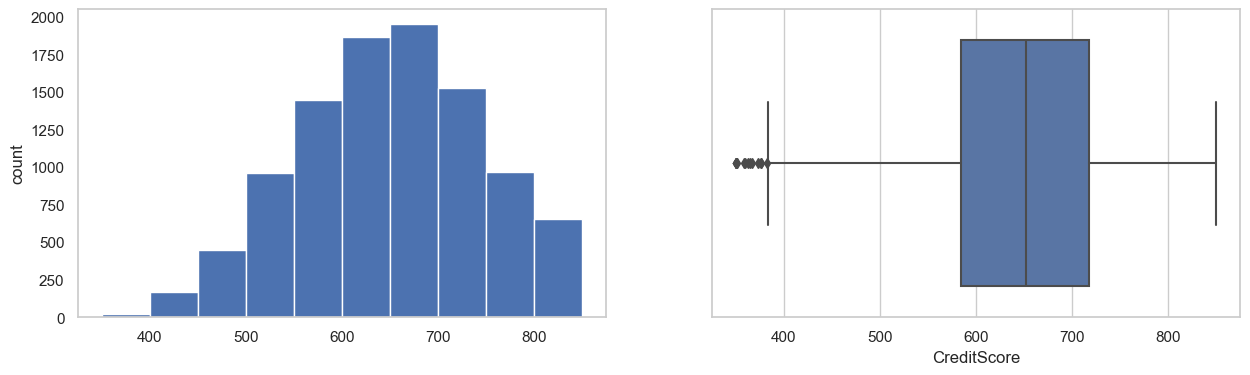

Age
----------
Skewness : 1.01
kurtosis : 1.4
--------------------


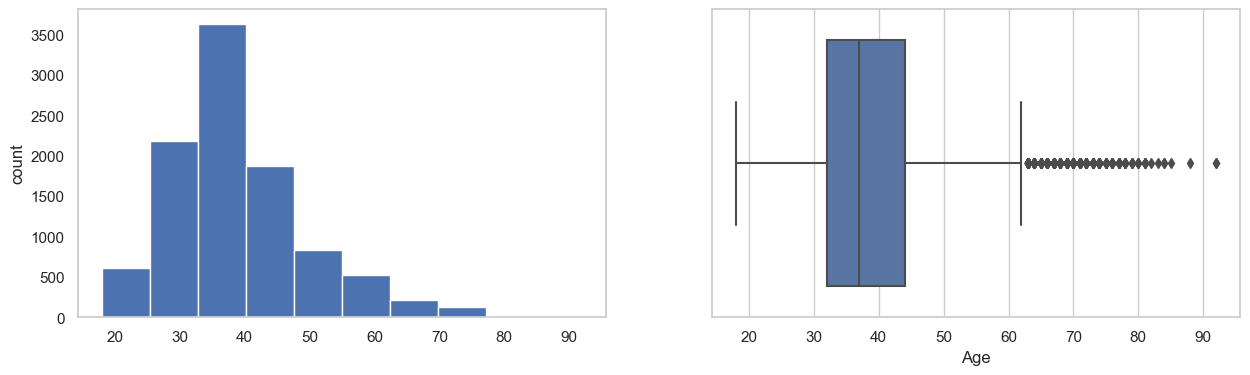

Tenure
----------
Skewness : 0.01
kurtosis : -1.17
--------------------


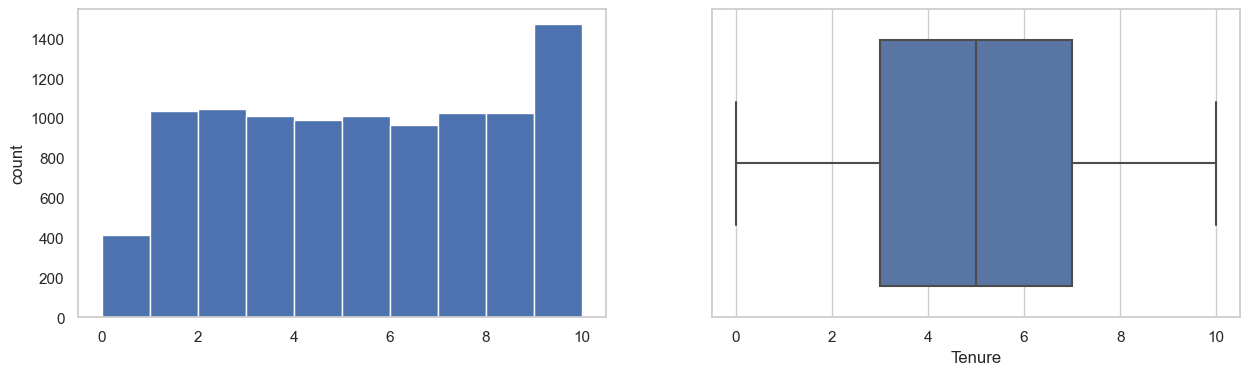

EstimatedSalary
----------
Skewness : 0.0
kurtosis : -1.18
--------------------


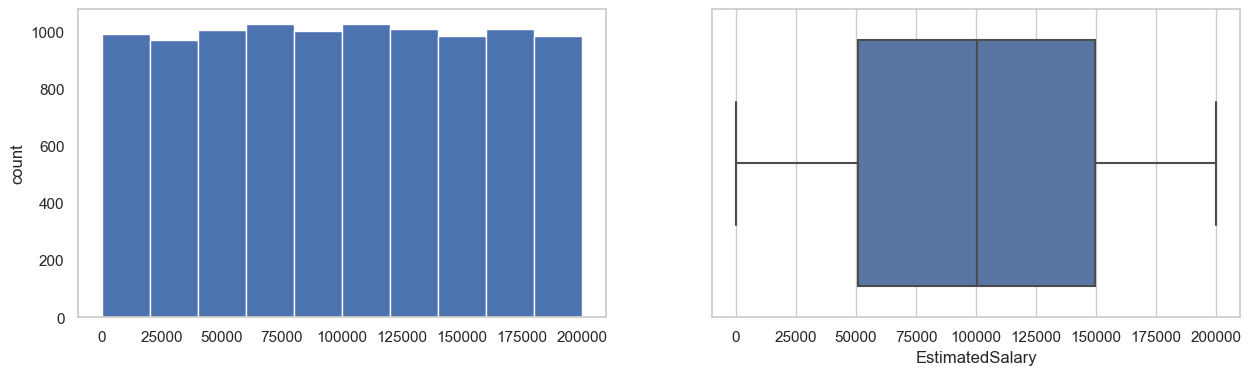

Balance
----------
Skewness : -0.14
kurtosis : -1.49
--------------------


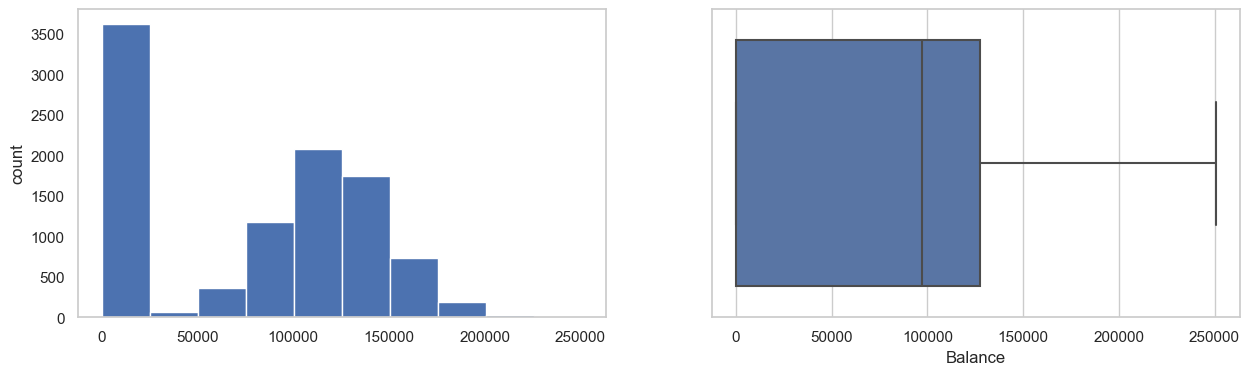

In [40]:
for col in num_cols:
    print(col)
    print("-"*10)
    print('Skewness :', round(data_1[col].skew(), 2))
    print('kurtosis :',round(data_1[col].kurtosis(),2))
    print("-"*20)
    sns.set(style="whitegrid")
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    data_1[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data_1[col])
    plt.show()

##### Step 3.5. Handling Outliers

###### Inference from above visuals:
    1. We could see that Tenure, and Estimated Salary have almost zero skewness and dont have any outliers. (Though they both are Platykurtic)
    2. Credit Score and Age have outliers.(We need to hnadle them)
    3. Around 3500 records (35%) of Balance is 0 and the Balance column is somewhat right skewed

In Europe, a good credit score for an individual typically falls within the range of 670 to 739. This range is generally considered "good" or "acceptable" by lenders, meaning individuals in this range are viewed as lower-risk borrowers. Scores above 740 are considered "very good" or "excellent", and those below 580 are considered "fair" or "poor

In [41]:
# Handling the Outliers in CreditScore column
# Calculating the interquartile range for CreditScore

q1_CC = data_1["CreditScore"].quantile(0.25)
q3_CC = data_1["CreditScore"].quantile(0.75)

IQR_CC = q3_CC-q1_CC

lower_limit_CC = q1_CC-(1.5*(IQR_CC))
upper_limit_CC = q3_CC + (1.5*(IQR_CC))

print(f"q1:  {q1_CC}")
print(f"q3:  {q3_CC}")
print(f"IQR:  {IQR_CC}")
print(f"lower_limit:  {lower_limit_CC}")
print(f"upper_limit:  {upper_limit_CC}")


q1:  584.0
q3:  718.0
IQR:  134.0
lower_limit:  383.0
upper_limit:  919.0


In [42]:
(data_1["CreditScore"]<lower_limit_CC).sum()

15

In [43]:
(data_1["CreditScore"]>upper_limit_CC).sum()

0

In [44]:
data_1[data_1["CreditScore"]<lower_limit_CC]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
8,376,Germany,Female,29.0,4,119346.88,115046.74,4,No,No,1
943,376,France,Female,46.0,6,157333.69,0.00,1,No,No,1
1194,363,Spain,Female,28.0,6,100615.14,146098.43,3,No,No,1
1406,359,France,Female,44.0,6,146955.71,128747.69,1,No,No,1
1632,350,Spain,Male,54.0,1,191973.49,152677.48,1,Yes,Yes,1
1839,350,Germany,Male,39.0,0,123602.11,109733.20,2,No,No,1
1963,358,Spain,Female,52.0,8,141959.11,143542.36,3,No,No,1
2474,351,Germany,Female,57.0,4,169621.69,163146.46,1,No,No,1
2580,365,Germany,Male,30.0,0,81537.85,127760.07,1,No,No,1
8155,367,Spain,Male,42.0,6,168816.73,93608.28,1,No,No,1


###### Inference from the 15 records low credit score outliers in which all of them have exited the bank

    1. Looks like Geography and Gender didn't affect these low values of Credit Score
    2. Around 3/4 th of these outliers had the following charateristcis:
        1. Sufficient Balance
        2. Had only 1 product of the Bank
        3. Didnt have a credit card (low credit score)
        4. Were not an ACTIVE member of the bank
        5. HAVE EXITED THE BANK
        
        Which may imply self-sufficient customers who dont borrow money and not much into the bank activities which brings into notice their age as well ---- most of them around 50 years of age
    
    3. 1/4TH of them have:
        1. Zero balance
        2. Had credit card 
        
        which may imply they may have exited without paying the credit card bill
        

    4. So these 15 outliers may be crucial for the model to study patterns and we neeed to treat them instead of removing 

In [45]:
# Handling the Outliers in Age column
# Calculating the interquartile range for Age

q1_A = data_1["Age"].quantile(0.25)
q3_A = data_1["Age"].quantile(0.75)

IQR_A = q3_A-q1_A

lower_limit_A = q1_A-(1.5*(IQR_A))
upper_limit_A = q3_A + (1.5*(IQR_A))

print(f"q1:  {q1_A}")
print(f"q3:  {q3_A}")
print(f"IQR:  {IQR_A}")
print(f"lower_limit:  {lower_limit_A}")
print(f"upper_limit:  {upper_limit_A}")


q1:  32.0
q3:  44.0
IQR:  12.0
lower_limit:  14.0
upper_limit:  62.0


In [46]:
(data_1["Age"]<lower_limit_A).sum()

0

In [47]:
(data_1["Age"]>upper_limit_A).sum()

359

In [48]:
((data_1["Age"]>upper_limit_A).sum())/len(data_1["Age"]>upper_limit_A) * 100

3.5900000000000003

In [49]:
data_1[data_1["Age"]>upper_limit_A]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
59,511,Spain,Female,66.0,4,1643.11,0.00,1,No,No,1
86,652,Spain,Female,75.0,10,114675.75,0.00,2,Yes,Yes,0
105,670,Spain,Female,65.0,1,177655.68,0.00,1,Yes,Yes,1
159,646,France,Female,73.0,6,104719.66,97259.25,1,Yes,Yes,0
182,510,France,Male,65.0,2,48071.61,0.00,2,Yes,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...
9754,656,Germany,Male,68.0,7,186574.68,153545.11,1,Yes,Yes,0
9766,445,France,Male,64.0,2,43678.06,136770.67,1,Yes,Yes,0
9833,595,Germany,Female,64.0,2,89935.73,105736.32,1,Yes,Yes,1
9895,521,France,Female,77.0,6,49054.10,0.00,2,Yes,Yes,0


In [50]:
data_1_age_out = data_1[data_1["Age"]>upper_limit_A]

data_1_age_out.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
59,511,Spain,Female,66.0,4,1643.11,0.00,1,No,No,1
86,652,Spain,Female,75.0,10,114675.75,0.00,2,Yes,Yes,0
105,670,Spain,Female,65.0,1,177655.68,0.00,1,Yes,Yes,1
159,646,France,Female,73.0,6,104719.66,97259.25,1,Yes,Yes,0
182,510,France,Male,65.0,2,48071.61,0.00,2,Yes,Yes,0


In [51]:
data_1_age_out.describe(include= "all")

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
count,359.000000,359,359,359.000000,359.000000,359.000000,359.000000,359.000000,359,359,359.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,Yes,Yes,NaN
freq,NaN,182,192,NaN,NaN,NaN,NaN,NaN,300,300,NaN
mean,657.005571,NaN,NaN,69.270195,4.944290,97883.247354,74477.573649,1.509749,NaN,NaN,0.203343
std,95.515713,NaN,NaN,5.237059,2.982671,57499.034723,62335.296038,0.583085,NaN,NaN,0.403047
min,408.000000,NaN,NaN,63.000000,0.000000,502.700000,0.000000,1.000000,NaN,NaN,0.000000
25%,596.000000,NaN,NaN,65.000000,2.000000,49530.100000,0.000000,1.000000,NaN,NaN,0.000000
50%,657.000000,NaN,NaN,68.000000,5.000000,97893.400000,95039.120000,1.000000,NaN,NaN,0.000000
75%,720.000000,NaN,NaN,72.000000,8.000000,145873.755000,126389.985000,2.000000,NaN,NaN,0.000000


In [52]:
data_1_age_out['Geography'].unique()

array(['Spain', 'France', 'Germany'], dtype=object)

In [53]:
data_1_age_out[(data_1_age_out["Age"]>62) & (data_1_age_out["Age"]<70)]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
59,511,Spain,Female,66.0,4,1643.11,0.00,1,No,No,1
105,670,Spain,Female,65.0,1,177655.68,0.00,1,Yes,Yes,1
182,510,France,Male,65.0,2,48071.61,0.00,2,Yes,Yes,0
235,585,France,Female,67.0,5,93146.11,113978.97,2,Yes,Yes,0
244,659,Germany,Male,67.0,6,45071.09,117411.60,1,Yes,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...
9734,733,France,Male,64.0,3,75272.63,0.00,2,Yes,Yes,0
9748,610,Germany,Female,69.0,5,192743.06,86038.21,3,No,No,1
9754,656,Germany,Male,68.0,7,186574.68,153545.11,1,Yes,Yes,0
9766,445,France,Male,64.0,2,43678.06,136770.67,1,Yes,Yes,0


In [54]:
(((data_1_age_out["Age"]>62) & (data_1_age_out["Age"]<70)) & data_1_age_out["Exited"] == 1).sum()

58

In [55]:
data_1_age_out[(data_1_age_out["Age"]>=70) & (data_1_age_out["Age"]<92)]

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
86,652,Spain,Female,75.0,10,114675.75,0.00,2,Yes,Yes,0
159,646,France,Female,73.0,6,104719.66,97259.25,1,Yes,Yes,0
231,673,France,Male,72.0,1,111981.19,0.00,2,Yes,Yes,0
253,681,France,Female,79.0,0,170968.99,0.00,2,Yes,Yes,0
311,652,France,Female,80.0,4,188603.07,0.00,2,Yes,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...
9672,649,Germany,Male,78.0,4,142566.75,68345.86,2,Yes,Yes,0
9735,667,Germany,Male,70.0,3,20881.96,77356.92,2,Yes,Yes,0
9737,659,Spain,Male,78.0,2,49978.67,151675.65,1,Yes,Yes,0
9895,521,France,Female,77.0,6,49054.10,0.00,2,Yes,Yes,0


In [56]:
(((data_1_age_out["Age"]>=70) & (data_1_age_out["Age"]<92)) & data_1_age_out["Exited"] == 1).sum()

15

We can infer from the above steps that out of 359 Age outliers ( > 62 and < 92) only 73 have exited the bank. The others are still retaining. Here also we can treat the outliers and check 

###### Step 3.5.1 Treating outliers in Credit Score

In [57]:
data_1["sqrt_CreditScore"]=data_1["CreditScore"]**0.5
data_1.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore
0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711
2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656
3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357
4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608
5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759


In [58]:
data_1["Log_CreditScore"]=np.log(data_1["CreditScore"])
data_1.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore
0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105
2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175
3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600
4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651
5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236


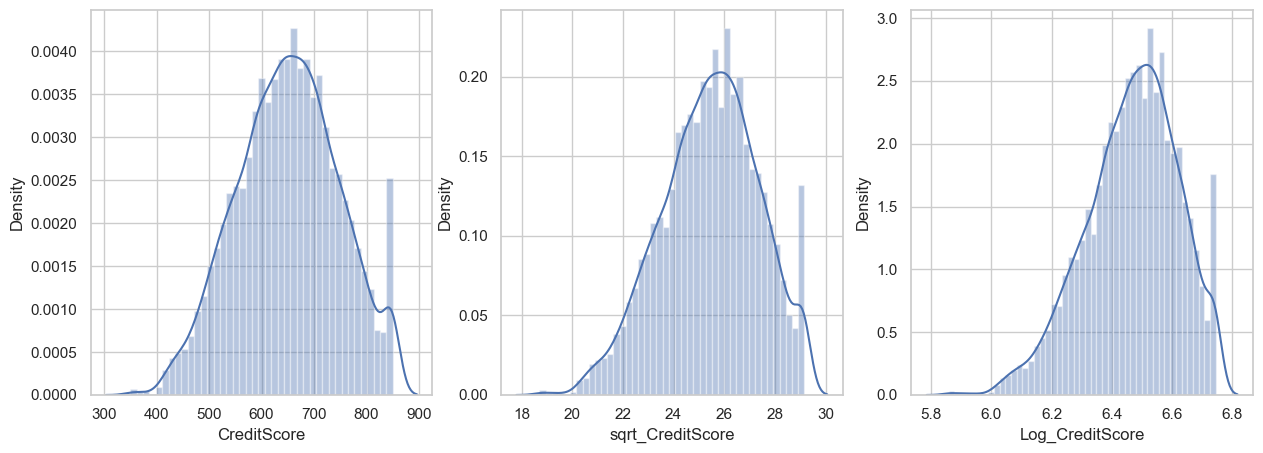

In [59]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.distplot(data_1["CreditScore"],ax=axes[0])
sns.distplot(data_1["sqrt_CreditScore"],ax=axes[1])
sns.distplot(data_1["Log_CreditScore"],ax=axes[2])

plt.show()

Both the transformations failed to give us a likely normal distribution. So we can remove the outliers in credit score

In [60]:
data_2 = data_1[(data_1["CreditScore"]>lower_limit_CC)].reset_index()

In [61]:
data_2.shape

(9984, 14)

###### Step 3.5.1 Treating outliers in Age

In [62]:
data_2["sqrt_Age"]=data_2["Age"]**0.5
data_2.head()

,index,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore,sqrt_Age
0,0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105,6.480741
1,2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175,6.403124
2,3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600,6.480741
3,4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651,6.244998
4,5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236,6.557439


In [63]:
data_2["Log_Age"]=np.log(data_2["Age"])
data_2.head()

,index,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore,sqrt_Age,Log_Age
0,0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105,6.480741,3.737670
1,2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175,6.403124,3.713572
2,3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600,6.480741,3.737670
3,4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651,6.244998,3.663562
4,5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236,6.557439,3.761200


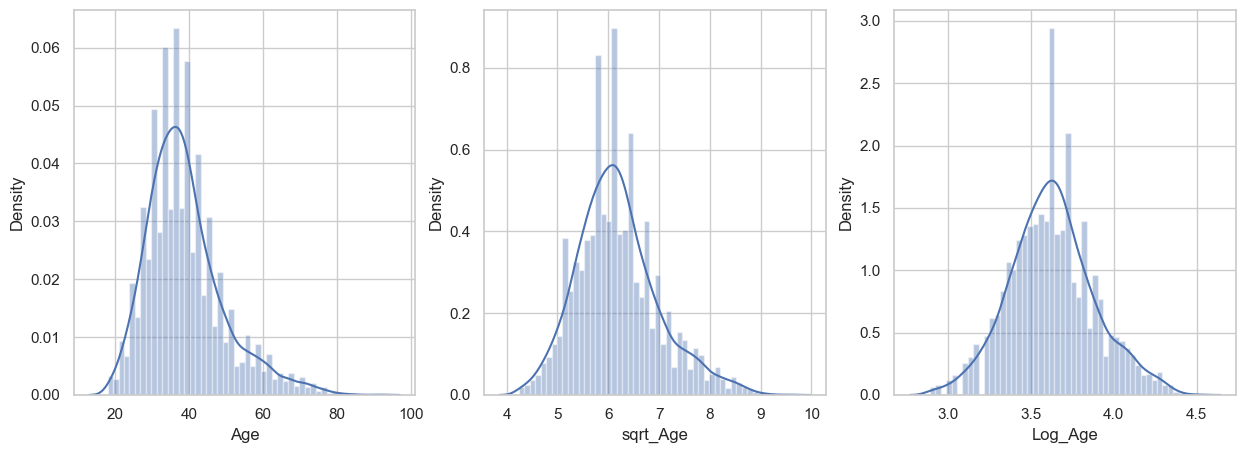

In [64]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.distplot(data_2["Age"],ax=axes[0])
sns.distplot(data_2["sqrt_Age"],ax=axes[1])
sns.distplot(data_2["Log_Age"],ax=axes[2])

plt.show()

We can infer from above that log age is giving us a normal curve so we can use that.

###### Bivariate Analysis between numerical columns

<Axes: xlabel='CreditScore', ylabel='Log_Age'>

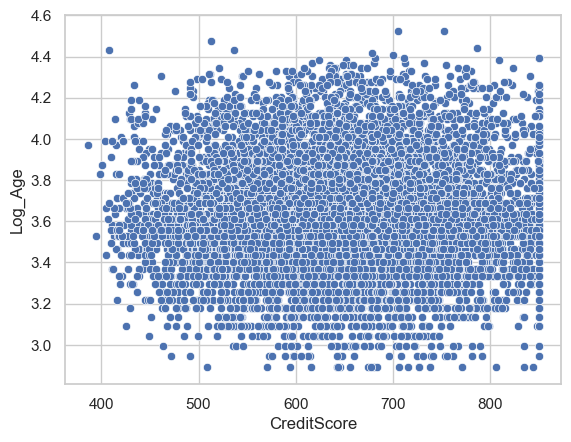

In [65]:
sns.scatterplot(x=data_2['CreditScore'], 
                y=data_2['Log_Age']) 

<Axes: xlabel='CreditScore', ylabel='Balance'>

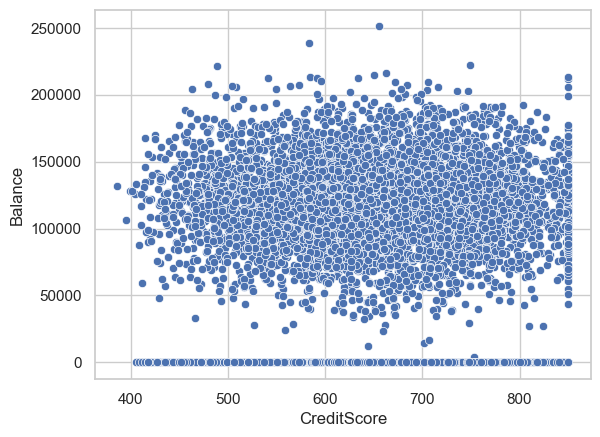

In [66]:
sns.scatterplot(x=data_2['CreditScore'], 
                y=data_2['Balance']) 

<Axes: xlabel='CreditScore', ylabel='EstimatedSalary'>

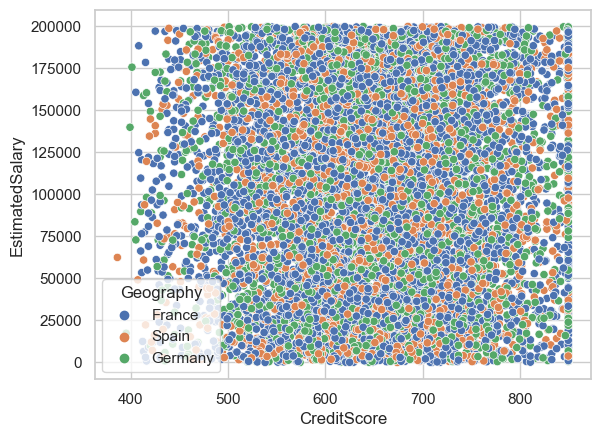

In [67]:
sns.scatterplot(x=data_2['CreditScore'], y=data_2['EstimatedSalary'], hue=data_2['Geography']) 


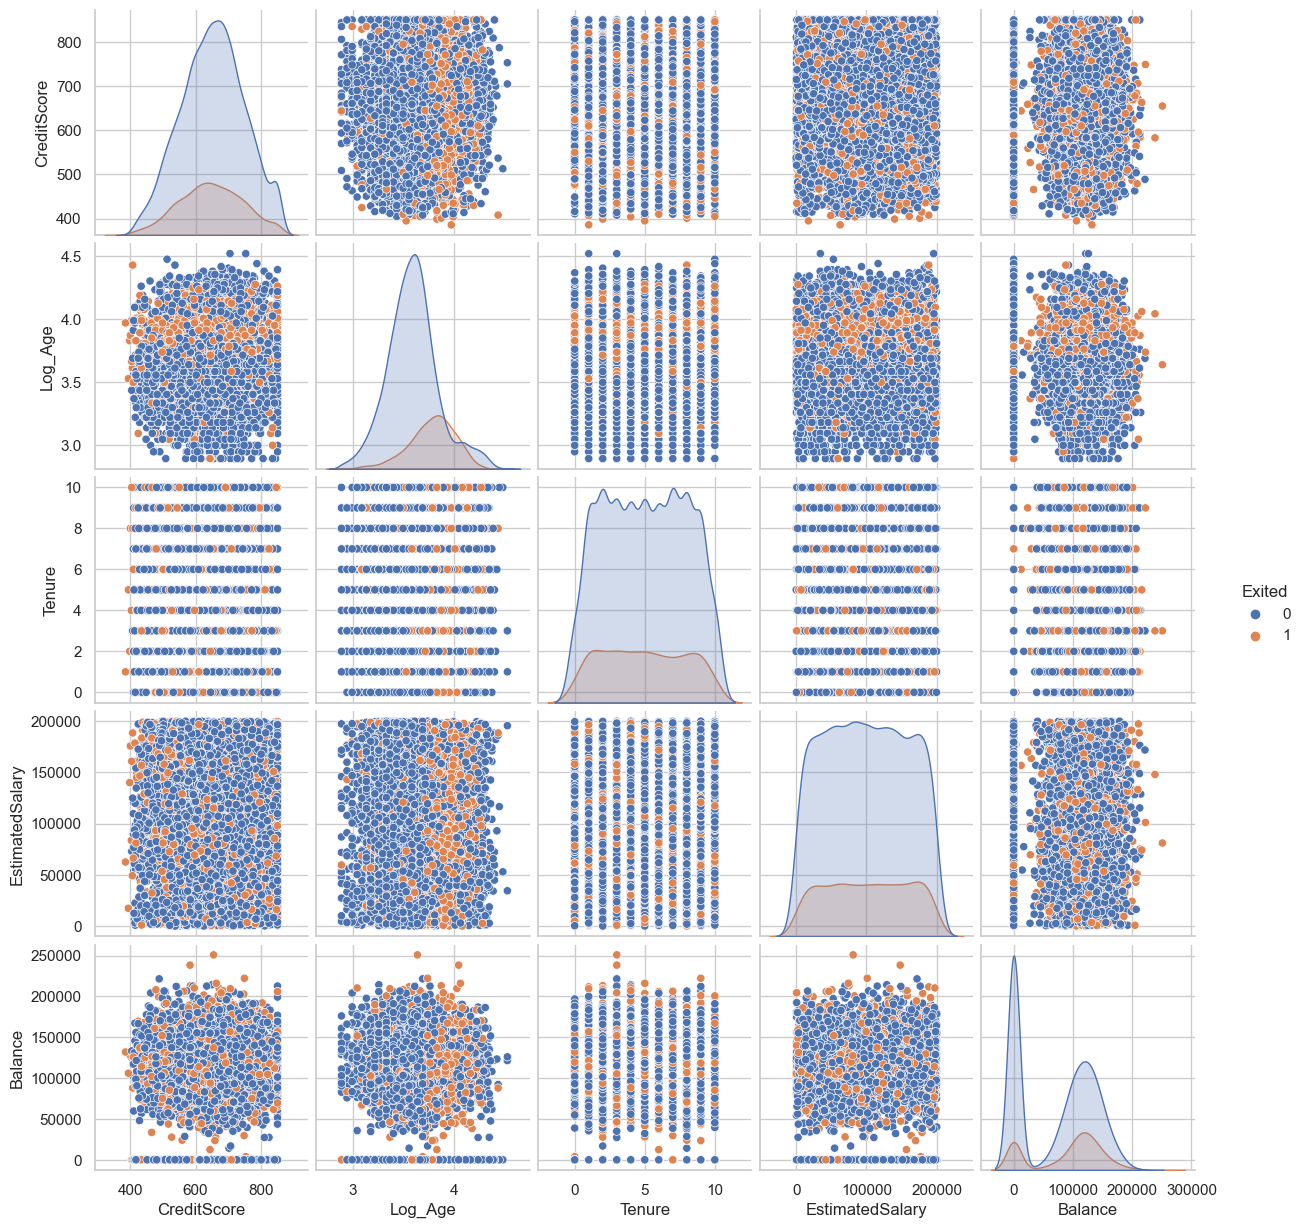

In [68]:
sns.pairplot(data = data_2[['CreditScore','Log_Age','Tenure','EstimatedSalary','Balance','Exited']],hue = 'Exited')

###### Correlation among the numerical columns

In [69]:
data_corr = data_2[['CreditScore','Log_Age','Tenure','EstimatedSalary','Balance']]
data_corr.corr()

,CreditScore,Log_Age,Tenure,EstimatedSalary,Balance
CreditScore,1.000000,-0.004225,-0.000357,0.002054,0.007166
Log_Age,-0.004225,1.000000,-0.011503,-0.007083,0.030617
Tenure,-0.000357,-0.011503,1.000000,0.008470,-0.011884
EstimatedSalary,0.002054,-0.007083,0.008470,1.000000,0.012355
Balance,0.007166,0.030617,-0.011884,0.012355,1.000000


<Axes: >

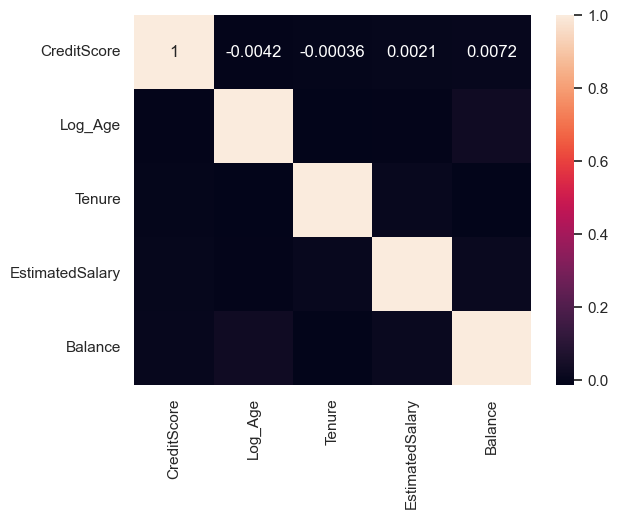

In [70]:
sns.heatmap(data_corr.corr(), annot=True)

###### Step 6. Categorical columns

In [71]:
data_2.shape

(9984, 16)

In [72]:
#Number of customers who have not exited the Bank out of 10000

(data_2["Exited"]==0).sum()

7963

In [73]:
data_2.head()

,index,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore,sqrt_Age,Log_Age
0,0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105,6.480741,3.737670
1,2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175,6.403124,3.713572
2,3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600,6.480741,3.737670
3,4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651,6.244998,3.663562
4,5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236,6.557439,3.761200


In [74]:
cat_cols = ['Geography','Gender','HasCrCard','IsActiveMember']

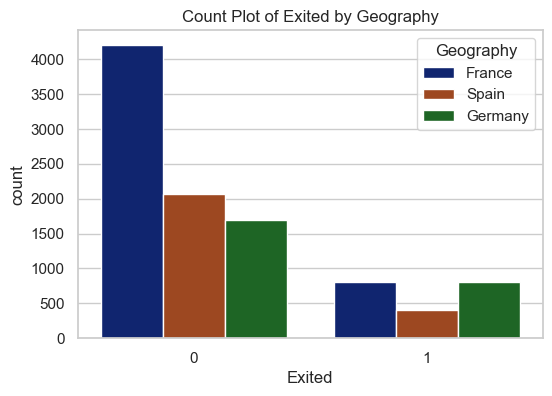

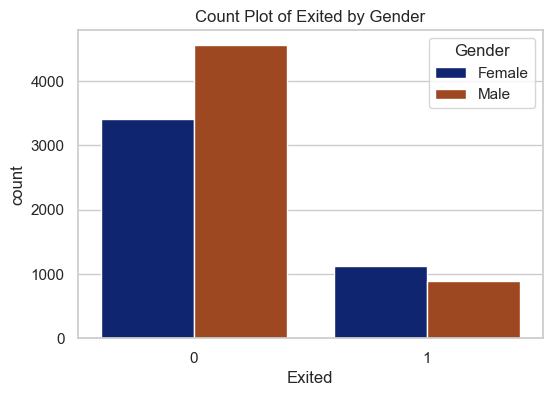

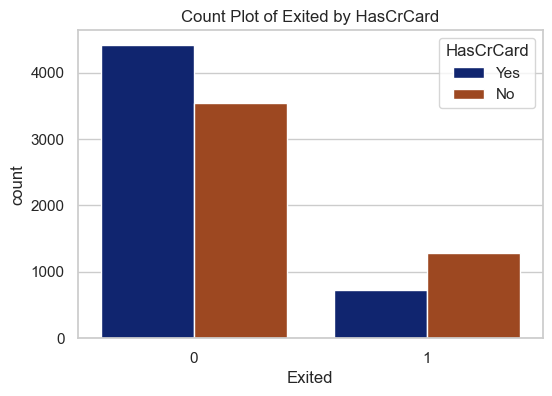

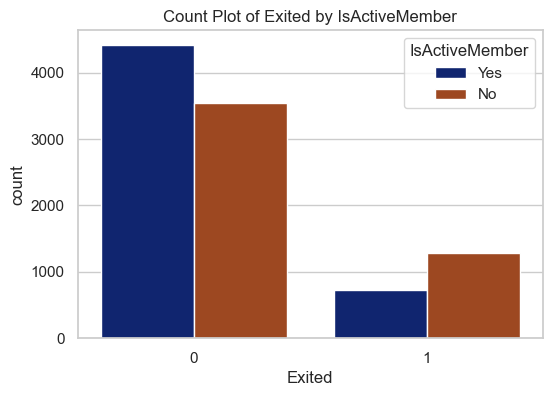

In [75]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.set(style="whitegrid")
    sns.countplot(x='Exited', hue=col, data=data_2, palette='dark')
    plt.title(f'Count Plot of Exited by {col}')
    plt.show()


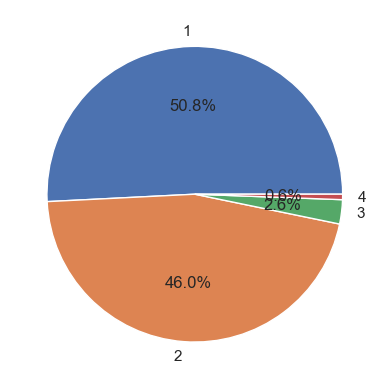

In [76]:
x = data_2['NumOfProducts'].value_counts() 
plt.pie(x.values, 
        labels=x.index, 
        autopct='%1.1f%%') 
plt.show() 

In [77]:
data_2.head()

,index,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore,sqrt_Age,Log_Age
0,0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105,6.480741,3.737670
1,2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175,6.403124,3.713572
2,3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600,6.480741,3.737670
3,4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651,6.244998,3.663562
4,5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236,6.557439,3.761200


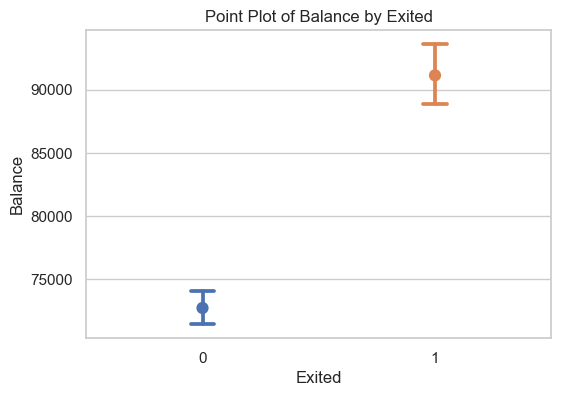

In [78]:
plt.figure(figsize=(6, 4))
sns.pointplot(x='Exited', y='Balance', data=data_2, palette="deep", capsize=.1)
plt.title('Point Plot of Balance by Exited')
plt.show()

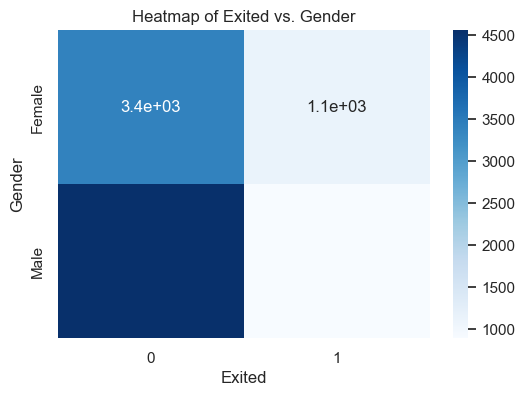

In [79]:
ct = pd.crosstab(data_2['Gender'], data_2['Exited'])
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, cmap="Blues")
plt.title('Heatmap of Exited vs. Gender')
plt.show()

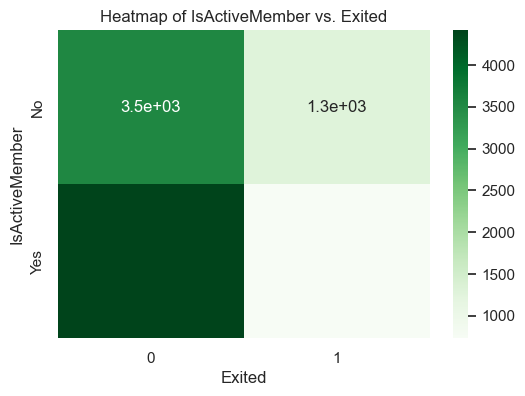

In [80]:
ct = pd.crosstab(data_2['IsActiveMember'], data_2['Exited'])
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, cmap="Greens")
plt.title('Heatmap of IsActiveMember vs. Exited')
plt.show()

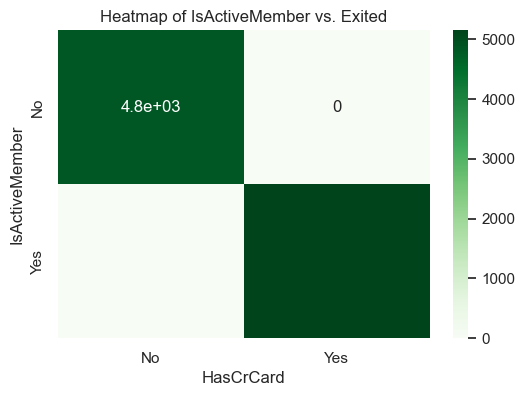

In [81]:
ct = pd.crosstab(data_2['IsActiveMember'], data_2['HasCrCard'])
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, cmap="Greens")
plt.title('Heatmap of IsActiveMember vs. Exited')
plt.show()

###### Step 7: Encoding Categorical Columns

In [82]:
data_2.head()

,index,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,sqrt_CreditScore,Log_CreditScore,sqrt_Age,Log_Age
0,0,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,24.879711,6.428105,6.480741,3.737670
1,2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,24.657656,6.410175,6.403124,3.713572
2,3,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,22.405357,6.218600,6.480741,3.737670
3,4,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,26.438608,6.549651,6.244998,3.663562
4,5,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,29.154759,6.745236,6.557439,3.761200


In [83]:
data_3 = data_2.drop(['index','Log_CreditScore','sqrt_CreditScore' ,'sqrt_Age', 'Age'], axis=1)
data_3.head()

,CreditScore,Geography,Gender,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Log_Age
0,619,France,Female,2,101348.88,0.00,1,Yes,Yes,1,3.737670
1,608,Spain,Female,1,112542.58,83807.86,1,Yes,Yes,0,3.713572
2,502,France,Female,8,113931.57,159660.80,3,No,No,1,3.737670
3,699,France,Female,1,93826.63,0.00,2,No,No,0,3.663562
4,850,Spain,Female,2,79084.10,125510.82,1,Yes,Yes,0,3.761200


In [84]:
data_3.columns.tolist()

['CreditScore',
 'Geography',
 'Gender',
 'Tenure',
 'EstimatedSalary',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'Exited',
 'Log_Age']

In [85]:
#cat_cols = ["Geography","Gender","HasCrCard","IsActiveMember","Exited"]
#df = pd.get_dummies(df, columns=[…], drop_first=True, dtype=int)

data_3 = pd.get_dummies(
    data_3,
    columns = ["Geography","Gender","HasCrCard","IsActiveMember"], 
    drop_first=True, dtype = int
)

#from sklearn.preprocessing import OneHotEncoder

#for col in cat_cols:
    #ohe = OneHotEncoder(sparse_output=False)
    #data_2[col] = ohe.fit_transform(data_2[col])

data_3.head()

,CreditScore,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,Log_Age,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,619,2,101348.88,0.00,1,1,3.737670,0,0,0,1,1
1,608,1,112542.58,83807.86,1,0,3.713572,0,1,0,1,1
2,502,8,113931.57,159660.80,3,1,3.737670,0,0,0,0,0
3,699,1,93826.63,0.00,2,0,3.663562,0,0,0,0,0
4,850,2,79084.10,125510.82,1,0,3.761200,0,1,0,1,1


##### Step 8 : Correlation 

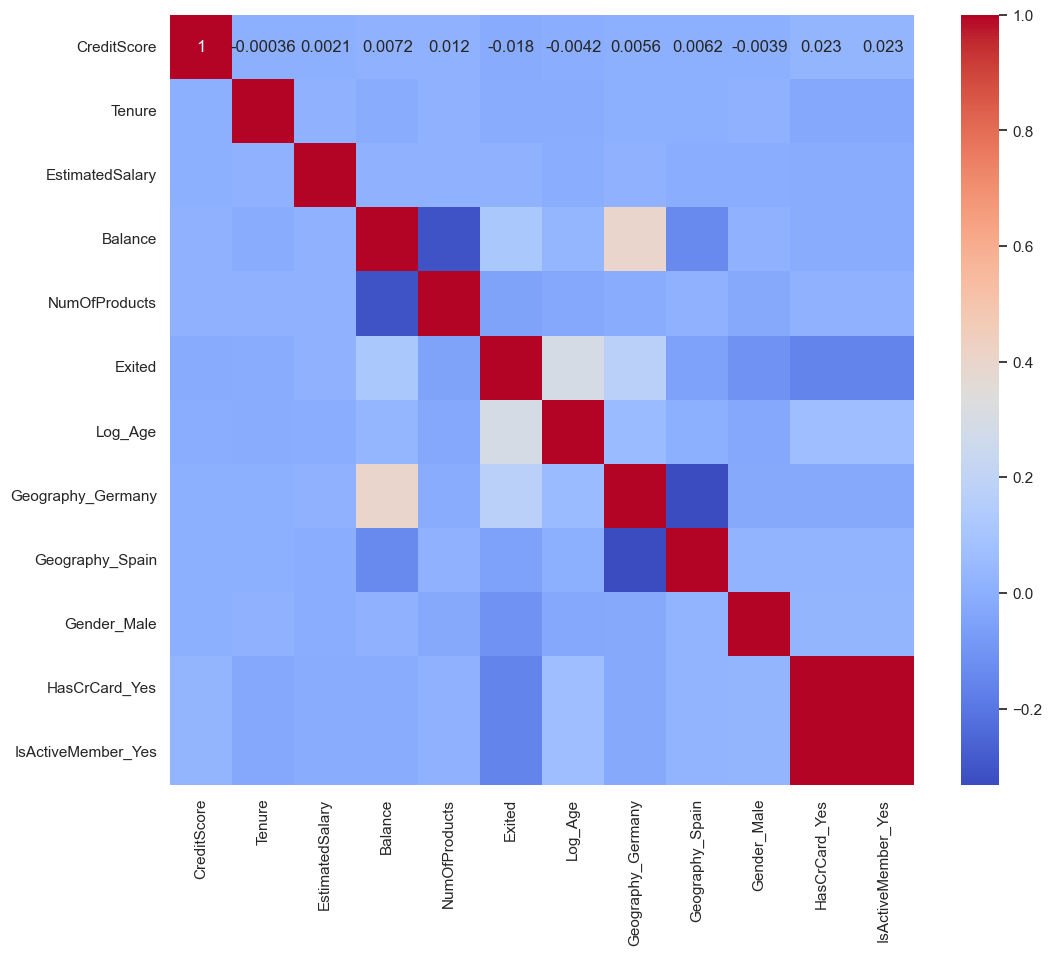

In [86]:
plt.figure(figsize=(12, 10))
sns.heatmap(data_3.corr(), annot=True, cmap="coolwarm")
plt.show()

#### We can see that HasCreditCard and IsActiveMember are correlated

##### Step 9: Standardization

In [87]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

X = data_3.drop(["Exited"], axis=1)
y = data_3["Exited"]
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.50215517, 0.2       , 0.50676345, ..., 0.        , 1.        ,
        1.        ],
       [0.47844828, 0.1       , 0.56273406, ..., 0.        , 1.        ,
        1.        ],
       [0.25      , 0.8       , 0.56967927, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.69612069, 0.7       , 0.21043581, ..., 0.        , 1.        ,
        1.        ],
       [0.83189655, 0.3       , 0.46446006, ..., 1.        , 0.        ,
        0.        ],
       [0.875     , 0.4       , 0.19096108, ..., 0.        , 0.        ,
        0.        ]])

##### Step 10: Train - Test Split

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size=0.30,random_state=42)

In [90]:
#X_train.head()

In [91]:
X_train.shape

(6988, 11)

In [92]:
#X_test.head()

In [93]:
X_test.shape

(2996, 11)

In [94]:
y_train.head()

1329    0
5639    0
9627    0
1777    1
6066    0
Name: Exited, dtype: int64

In [95]:
y_train.shape

(6988,)

In [96]:
y_test.head()

4896    0
8655    0
1780    0
9202    0
6224    0
Name: Exited, dtype: int64

In [97]:
y_test.shape

(2996,)

## Step 11: Training and Prediction using LOGISTIC REGRESSION

In [98]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train,y_train)

predictions_log_reg = log_reg.predict(X_test)

In [99]:
predictions_prob = log_reg.predict_proba(X_test)[:,1]
predictions_prob

array([0.07857944, 0.1249439 , 0.16838513, ..., 0.1914841 , 0.32638794,
       0.0641452 ])

## Step 12: Evaluation of Logistic Regression

In [100]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score 
from sklearn .metrics import roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

In [101]:
results = confusion_matrix(y_test, predictions_log_reg) 
results

array([[2290,   79],
       [ 481,  146]], dtype=int64)

In [102]:
accuracy_score(y_test, predictions_log_reg)

0.8130841121495327

## Our BANK CHURN Model's ACCURACY using LOGISTIC REGRESSION  is  81%

In [103]:
y_test[:10]

4896    0
8655    0
1780    0
9202    0
6224    0
2522    1
35      0
3501    0
4267    0
6620    0
Name: Exited, dtype: int64

In [104]:
predictions_log_reg[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

### CLASSIFICATION REPORT

In [105]:
print(classification_report(y_test,predictions_log_reg))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      2369
           1       0.65      0.23      0.34       627

    accuracy                           0.81      2996
   macro avg       0.74      0.60      0.62      2996
weighted avg       0.79      0.81      0.78      2996



In [106]:


auc = np.round(roc_auc_score(y_test, predictions_log_reg), 3)

print(F"Auc for our bank churn dataset is {auc}")

Auc for our bank churn dataset is 0.6


### PLOTTING THE ROC CURVE

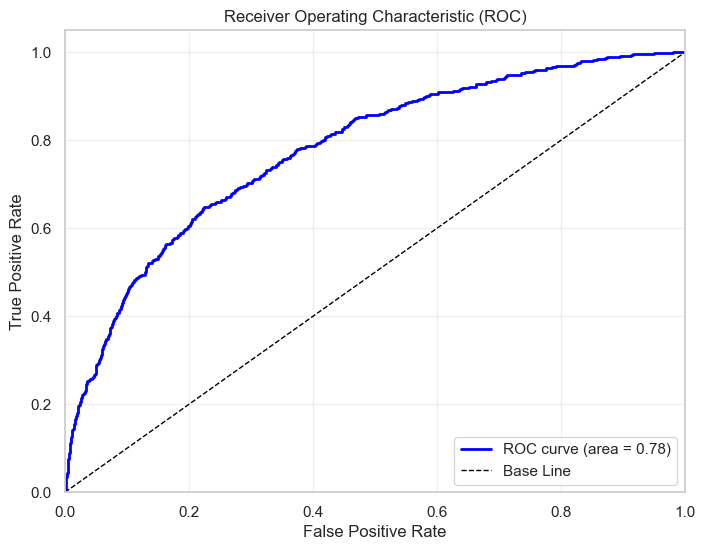

In [107]:
# Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, predictions_prob)

# Calculate AUC
roc_auc = roc_auc_score(y_test, predictions_prob)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,label=f'ROC curve (area = {roc_auc:.2f})')


# Diagonal line for random chance
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--',label='Base Line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


### SVM ALOGORITHM

Test Accuracy using SVM algorithm: 0.84
              precision    recall  f1-score   support

           0       0.84      0.98      0.91      2369
           1       0.81      0.30      0.43       627

    accuracy                           0.84      2996
   macro avg       0.83      0.64      0.67      2996
weighted avg       0.83      0.84      0.81      2996

Auc using SVM algorithm is 0.638


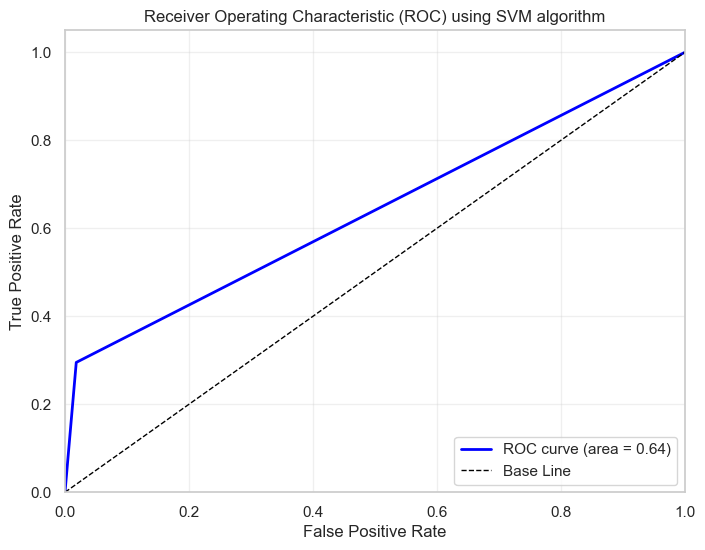

In [108]:
from sklearn.svm import SVC

#INITIALIZING THE ALGORITHM  TO A VARIABLE WITH SUITABLE PARAMETERS

svm_clf = SVC(
    kernel='rbf',      
    C=1.0,             
    gamma='scale',     
    probability=True,  
    random_state=42
)

#TRAINING
svm_clf.fit(X_train, y_train)


#TESTING
y_pred = svm_clf.predict(X_test)
y_prob = svm_clf.predict_proba(X_test)[:, 1]  # Probability of class “1”

#ACCURACY
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy using SVM algorithm: {acc:.2f}")

#EVALUATION METRICS - CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))


# EVALUATION METRICS - FPR, TPR, ROC CURVE, ROC - AUC CURVE

from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
auc = np.round(roc_auc_score(y_test, y_pred), 3)

print(F"Auc using SVM algorithm is {auc}")

#FPR, TPR and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

#AUC
roc_auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,label=f'ROC curve (area = {roc_auc:.2f})')


# Diagonal line for Base line
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--',label='Base Line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) using SVM algorithm')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


## Our BANK CHURN Model's ACCURACY using SVM ALGORITHM is  84%

### RANDOM FOREST CLASSIFIER

Test Accuracy using Random Forest Classifier : 0.857
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2369
           1       0.77      0.46      0.57       627

    accuracy                           0.86      2996
   macro avg       0.82      0.71      0.74      2996
weighted avg       0.85      0.86      0.84      2996

Auc using Random Forest algorithm is 0.638


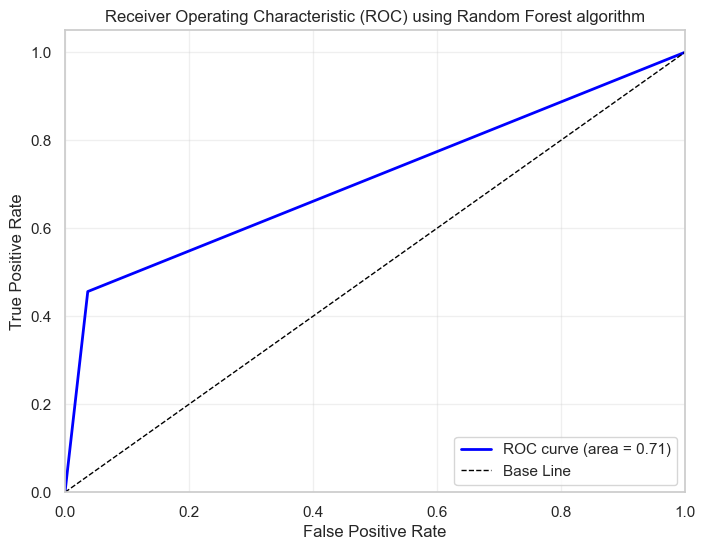

Out of Bag Score: 0.859


In [109]:
#INITIALIZING THE ALGORITHM  TO A VARIABLE WITH SUITABLE PARAMETERS

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,    # number of trees
    criterion='gini',    # split quality measure
    max_depth=None,      # no maximum depth
    min_samples_split=2, # default
    bootstrap=True,      # use bootstrap samples
    oob_score=True,      # enable out‑of‑bag scoring
    random_state=42
)

# TRAINING

rf_clf.fit(X_train, y_train)

# TESTING

y_pred = rf_clf.predict(X_test)


# ACCURACY 
from sklearn.metrics import accuracy_score, classification_report
print(f"Test Accuracy using Random Forest Classifier : {accuracy_score(y_test, y_pred):.3f}")


# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))


print(F"Auc using Random Forest algorithm is {auc}")

#FPR, TPR and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)


#AUC
roc_auc = roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,label=f'ROC curve (area = {roc_auc:.2f})')


# Diagonal line for Base line
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--',label='Base Line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) using Random Forest algorithm')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# OUT OF BAG SCORE:
print(f"Out of Bag Score: {rf_clf.oob_score_:.3f}")

## Our BANK CHURN Model's ACCURACY using RANDOM FOREST is  86%

# FEATURE IMPORTANCE SORTING 

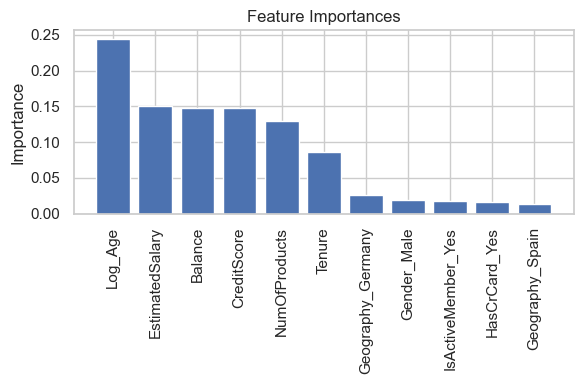

In [110]:
import matplotlib.pyplot as plt

importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(6,4))
plt.title("Feature Importances")
plt.bar(range(len(features)), importances[indices], align="center")
plt.xticks(range(len(features)), features[indices], rotation=90)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


### Customer Retention Strategies:  

### According to the data analysis , we can infer that older people tend to retain with the bank. The attention should be focused on younger people of age >20 < 30 by making them active customers, convincing them to use more of bank products like loan, credit cards etc, which eventually increase their retention intention and credit score. 

### K NEIGHBOUR CLASSIFIER ALGORITHM

Accuracy using KNN Algorithm : 0.833
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      2369
           1       0.66      0.41      0.51       627

    accuracy                           0.83      2996
   macro avg       0.76      0.68      0.70      2996
weighted avg       0.82      0.83      0.82      2996

Auc using KNN algorithm is 0.638


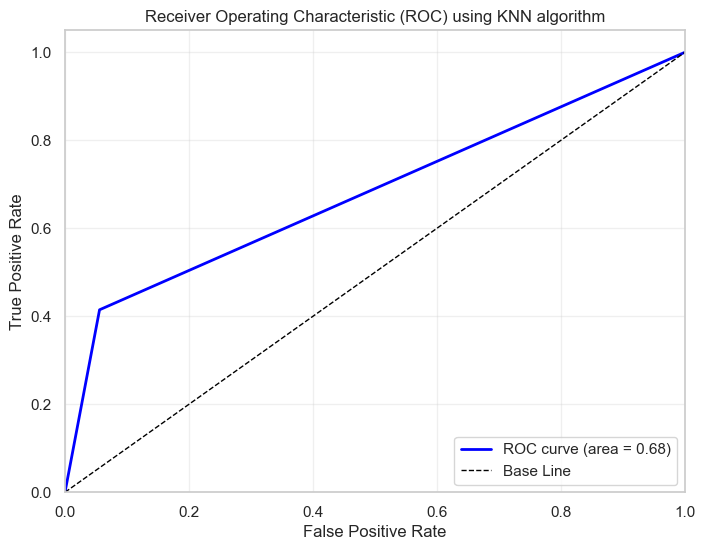

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


# STANDARDIZATION

scaler = StandardScaler()                                 
X_train_scaled = scaler.fit_transform(X_train)           
X_test_scaled  = scaler.transform(X_test)


#INITIALIZING THE ALGORITHM  TO A VARIABLE WITH SUITABLE PARAMETERS

knn = KNeighborsClassifier(
    n_neighbors=5,                                        # number of neighbors (k) :contentReference[oaicite:7]{index=7}
    weights='uniform',                                    # equal vote weight :contentReference[oaicite:8]{index=8}
    metric='minkowski',                                   # Minkowski distance (Euclidean if p=2) :contentReference[oaicite:9]{index=9}
    p=2                                                   # p=2 → Euclidean distance :contentReference[oaicite:10]{index=10}
)




# TRAINING:

knn.fit(X_train_scaled, y_train)                          # stores training data internally :contentReference[oaicite:11]{index=11}



# TESTING

y_pred = knn.predict(X_test_scaled)

print(f"Accuracy using KNN Algorithm : {accuracy_score(y_test, y_pred):.3f}")  
print(classification_report(y_test, y_pred))

print(F"Auc using KNN algorithm is {auc}")

#FPR, TPR and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

#AUC
roc_auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,label=f'ROC curve (area = {roc_auc:.2f})')


# Diagonal line for Base line
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--',label='Base Line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) using KNN algorithm')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()




## Our BANK CHURN Model's ACCURACY using KNN ALGORITHM is  83%

### XG BOOST ALGORITHM


In [112]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


Accuracy using XG Boost : 0.8648197596795728
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2369
           1       0.81      0.46      0.59       627

    accuracy                           0.86      2996
   macro avg       0.84      0.72      0.75      2996
weighted avg       0.86      0.86      0.85      2996

Auc using XG Boost algorithm is 0.638


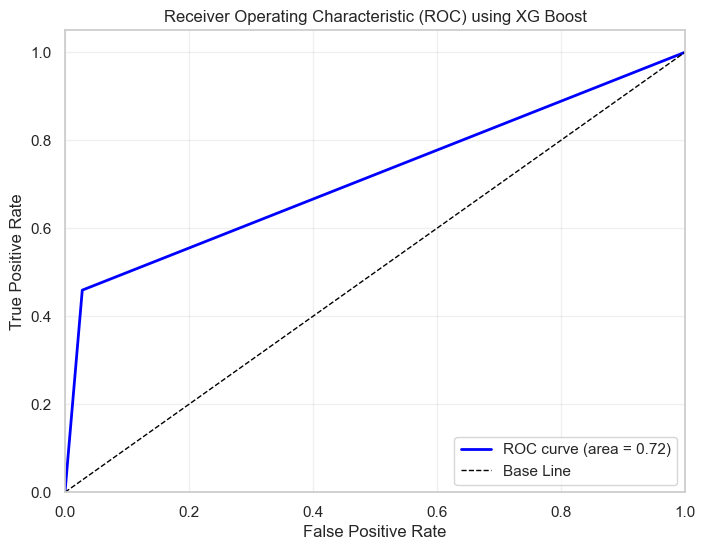

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best CV score: 0.8651988780372412


In [113]:
# INITIAL IMPORTS
import xgboost as xgb
from xgboost import XGBClassifier


#INITIALIZING THE ALGORITHM  TO A VARIABLE WITH SUITABLE PARAMETERS

xg_boost = XGBClassifier(
    n_estimators=100,         # number of trees
    max_depth=3,              # maximum tree depth
    learning_rate=0.1,        # step size shrinkage
    objective='binary:logistic',  # for binary classification
    use_label_encoder=False,  # disable legacy label encoder
    eval_metric='logloss',   # binary log-loss
    random_state=42
)



# TRAINING

xg_boost.fit(X_train, y_train)


#TESTING

y_pred = xg_boost.predict(X_test)
y_proba = xg_boost.predict_proba(X_test) 


# EVALUATION METRICS

print("Accuracy using XG Boost :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


print(F"Auc using XG Boost algorithm is {auc}")

#FPR, TPR and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

#AUC
roc_auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,label=f'ROC curve (area = {roc_auc:.2f})')


# Diagonal line for Base line
plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--',label='Base Line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) using XG Boost')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


# HYPER PARAMETER TUNING

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)


## Our BANK CHURN Model's ACCURACY using XG BOOST  is  86%